## Notebook - Inital Data Exploration (EDA)

In [1]:
%cd ..

c:\Users\campz\Documents\Grad School\Data Science - Communication\Donaldson


In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data = pd.read_csv("data/processed/yearly_cases_2021_2025.csv")
data.head()

,Disease Category,Disease,January,February,March,April,May,June,July,August,September,October,November,December,Yearly Cases,Yearly Rate,Year
0,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",14.0,11.0,8.0,9.0,6.0,12.0,9.0,11,6,9,11,13,119.0,4.0,2021
1,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",13.0,7.0,10.0,5.0,6.0,6.0,10.0,9,9,10,16,18,119.0,4.0,2022
2,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",23.0,20.0,33.0,20.0,27.0,27.0,23.0,18,12,29,19,40,291.0,9.8,2023
3,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",32.0,40.0,37.0,33.0,34.0,16.0,14.0,14,16,16,15,25,292.0,9.8,2024
4,Diseases Transmitted by Direct Contact and Res...,"Group A Streptococcal disease, invasive (iGAS)",24.0,32.0,20.0,22.0,25.0,20.0,14.0,12,16,19,33,24,263.0,8.0,2025


___

**Analysis #1**

Look at the yearly trend of disease categories exclusing COVID-19

In [4]:
first_plot_data = data.groupby(by = ["Disease Category", "Year"], as_index = False )[["Yearly Cases", "January", "February", "March", 
"April", "May", "June", "July", "August", "September", "October", "November", "December"]].sum()
first_plot_data.head(10)

,Disease Category,Year,Yearly Cases,January,February,March,April,May,June,July,August,September,October,November,December
0,Diseases Transmitted by Direct Contact and Res...,2021,525.0,38.0,46.0,33.0,36.0,39.0,55.0,50.0,56,31,51,49,41
1,Diseases Transmitted by Direct Contact and Res...,2022,507.0,41.0,37.0,36.0,34.0,30.0,169.0,276.0,158,71,41,52,59
2,Diseases Transmitted by Direct Contact and Res...,2023,758.0,68.0,46.0,75.0,55.0,64.0,75.0,68.0,71,49,67,46,74
3,Diseases Transmitted by Direct Contact and Res...,2024,1010.0,76.0,87.0,71.0,77.0,100.0,86.0,118.0,102,98,80,61,54
4,Diseases Transmitted by Direct Contact and Res...,2025,1748.0,127.0,126.0,138.0,129.0,147.0,169.0,156.0,138,134,117,122,133
5,Enteric Food and Waterborne Diseases,2021,1155.0,73.0,62.0,52.0,44.0,56.0,88.0,154.0,152,143,136,104,91
6,Enteric Food and Waterborne Diseases,2022,1603.0,61.0,77.0,118.0,100.0,145.0,206.0,201.0,170,187,136,98,104
7,Enteric Food and Waterborne Diseases,2023,1960.0,126.0,136.0,123.0,125.0,193.0,203.0,239.0,238,184,136,128,129
8,Enteric Food and Waterborne Diseases,2024,2131.0,154.0,170.0,113.0,151.0,168.0,172.0,269.0,273,197,183,144,137
9,Enteric Food and Waterborne Diseases,2025,2039.0,122.0,114.0,168.0,145.0,170.0,209.0,226.0,227,203,174,145,126


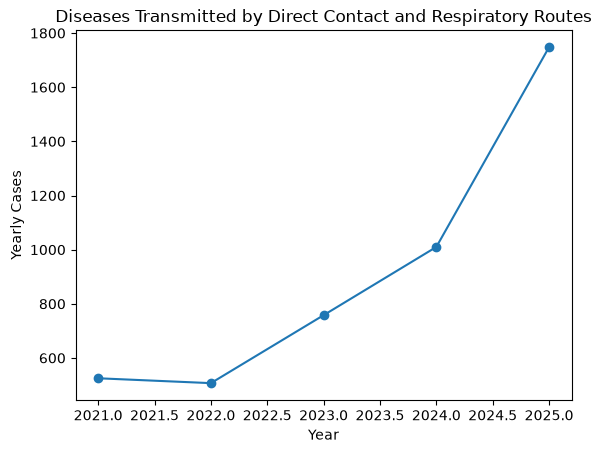

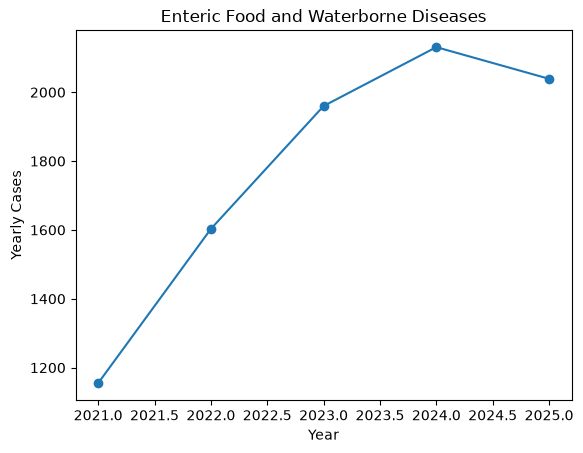

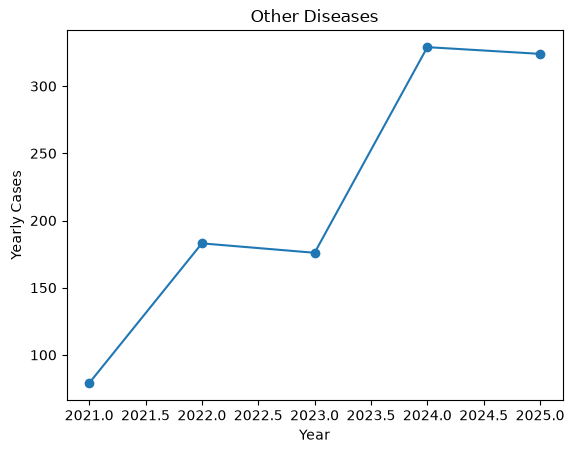

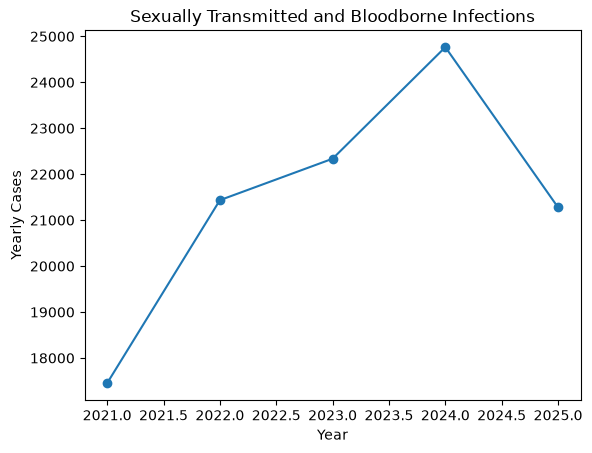

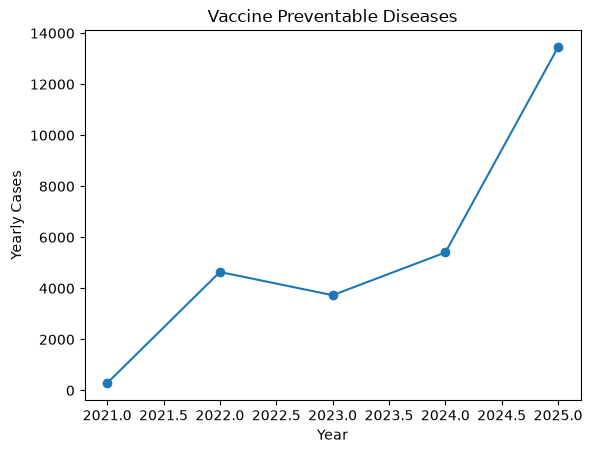

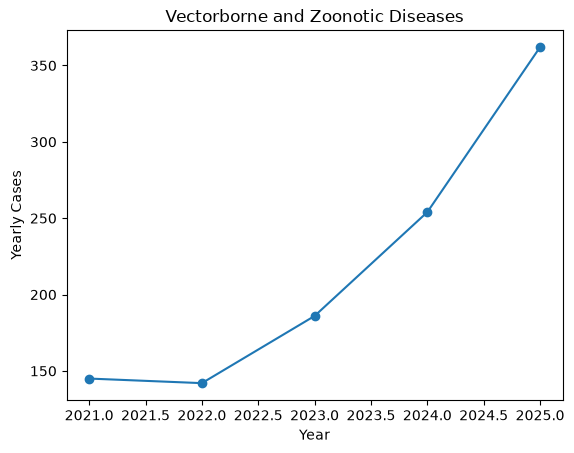

In [5]:
for cat in first_plot_data["Disease Category"].unique():
    cat_data = first_plot_data[first_plot_data["Disease Category"] == cat]
    
    plt.figure()
    plt.plot(
        cat_data["Year"],
        cat_data["Yearly Cases"], 
        marker = 'o'
    )
    plt.title(cat)
    plt.xlabel("Year")
    plt.ylabel("Yearly Cases")
    plt.show()

**Would be interesting to see monthly trends**

In [6]:
months = ["January", "February", "March", "April","May", "June", "July", "August", "September", "October", "November", "December"]

monthly_data = first_plot_data.melt(
    id_vars=["Disease Category", "Year"], value_vars=months, var_name="Month", value_name="Cases")

monthly_data["Date"] = pd.to_datetime(
    monthly_data["Year"].astype(str) + " " + monthly_data["Month"]
)
monthly_data

C:\Users\campz\AppData\Local\Temp\ipykernel_41660\2025994168.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_data["Date"] = pd.to_datetime(


,Disease Category,Year,Month,Cases,Date
0,Diseases Transmitted by Direct Contact and Res...,2021,January,38.0,2021-01-01
1,Diseases Transmitted by Direct Contact and Res...,2022,January,41.0,2022-01-01
2,Diseases Transmitted by Direct Contact and Res...,2023,January,68.0,2023-01-01
3,Diseases Transmitted by Direct Contact and Res...,2024,January,76.0,2024-01-01
4,Diseases Transmitted by Direct Contact and Res...,2025,January,127.0,2025-01-01
...,...,...,...,...,...
355,Vectorborne and Zoonotic Diseases,2021,December,0.0,2021-12-01
356,Vectorborne and Zoonotic Diseases,2022,December,1.0,2022-12-01
357,Vectorborne and Zoonotic Diseases,2023,December,2.0,2023-12-01
358,Vectorborne and Zoonotic Diseases,2024,December,4.0,2024-12-01


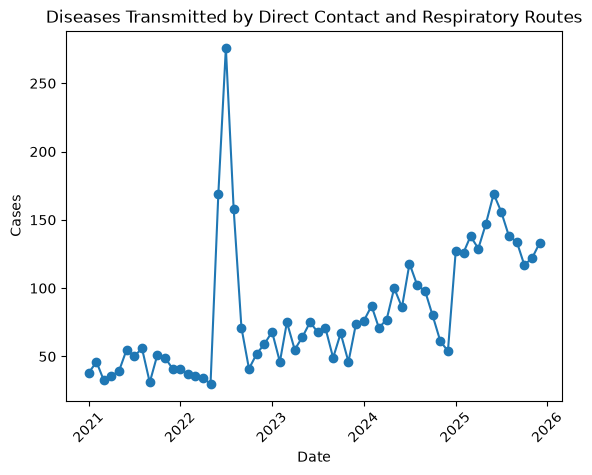

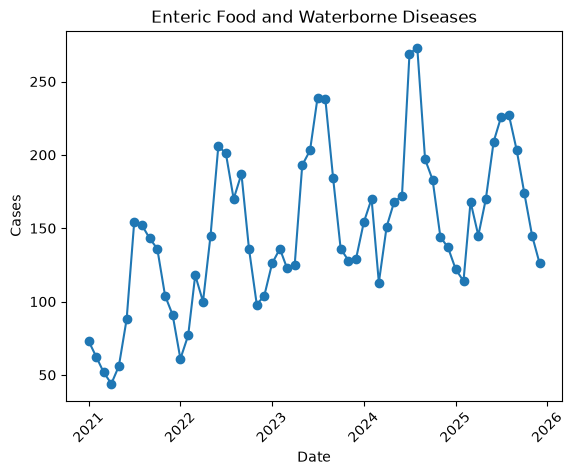

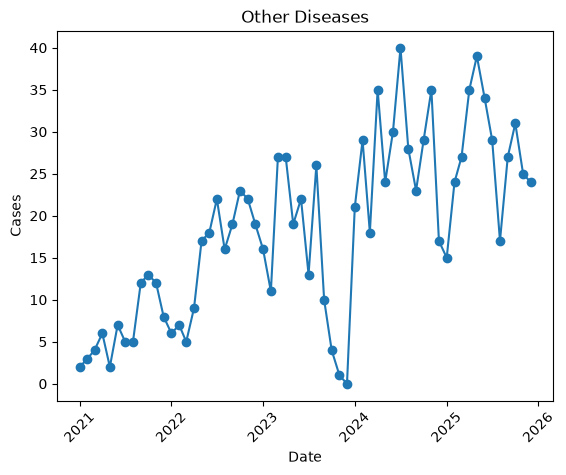

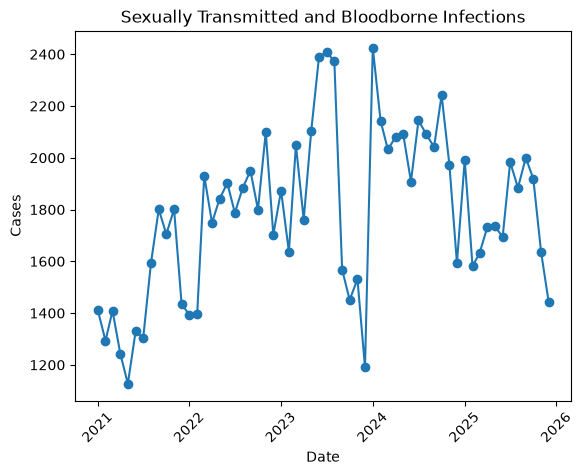

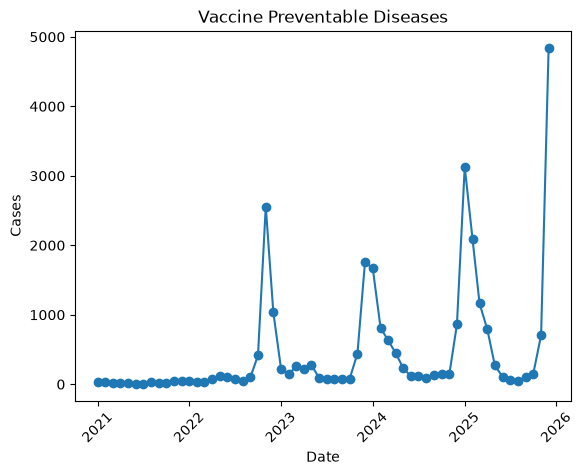

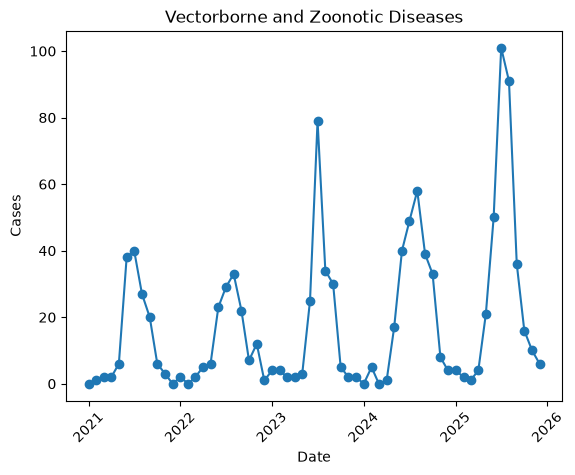

In [7]:
for cat in monthly_data["Disease Category"].unique():
    cat_data = monthly_data[monthly_data["Disease Category"] == cat].sort_values("Date")
    
    plt.plot(
        cat_data["Date"],
        cat_data["Cases"],
        marker="o"
    )

    plt.title(cat)
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.xticks(rotation=45)

    plt.show()

___ 

## Vaccine Preventable Diseases

In [ ]:
vacc_data = data[data['Disease Category'] == 'Vaccine Preventable Diseases']


Index(['Disease Category', 'Disease', 'January', 'February', 'March', 'April',
       'May', 'June', 'July', 'August', 'September', 'October', 'November',
       'December', 'Yearly Cases', 'Yearly Rate', 'Year'],
      dtype='str')

<StringDtype(na_value=nan)>

In [ ]:
vacc_mon_data = vacc_data.melt(
    id_vars=["Disease", "Year"], value_vars=months, var_name="Month", value_name="Cases")

vacc_mon_data["Date"] = pd.to_datetime(
    monthly_data["Year"].astype(str) + " " + monthly_data["Month"]
)

vacc_mon_data

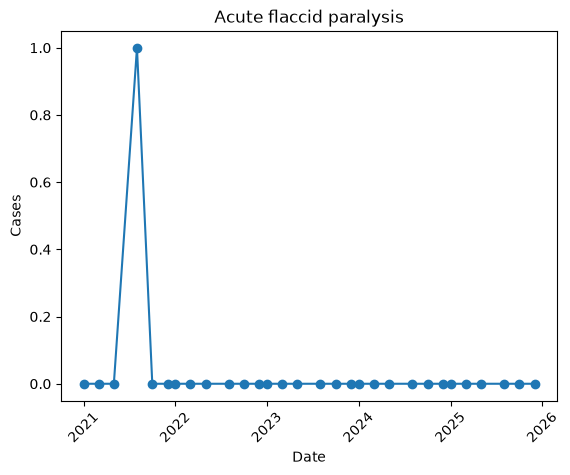

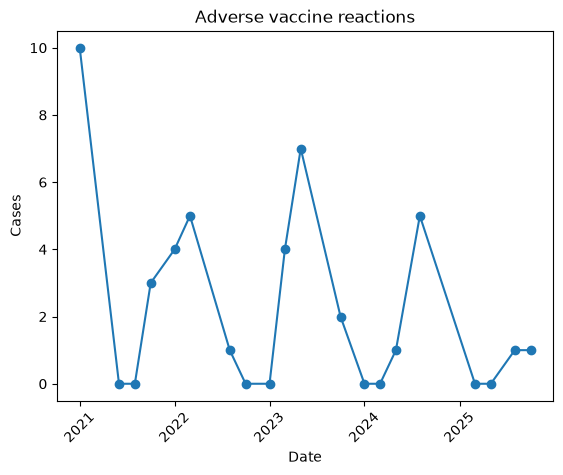

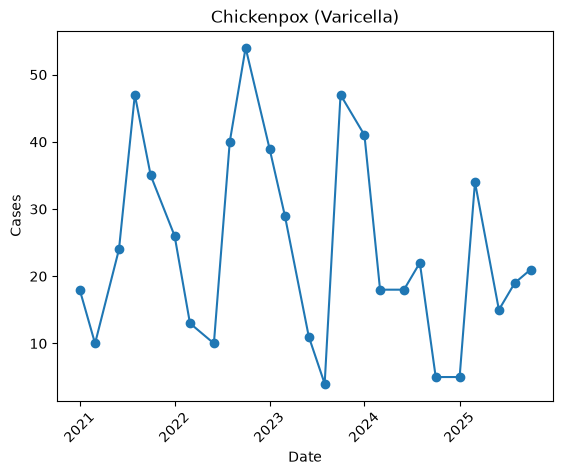

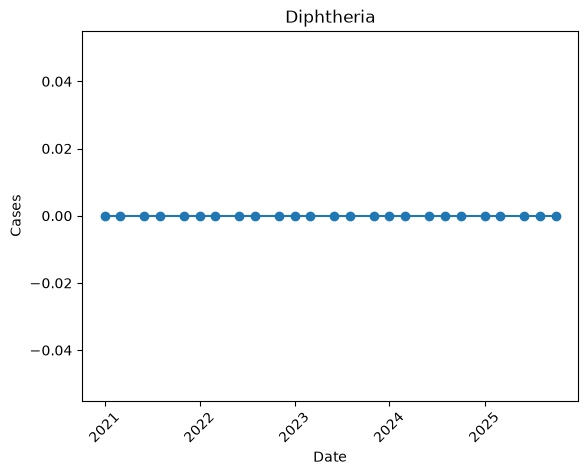

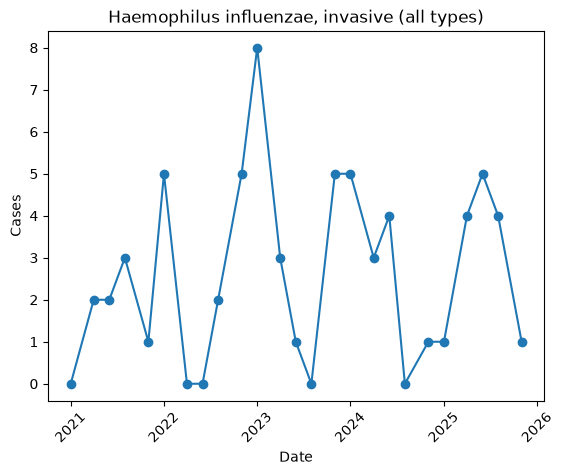

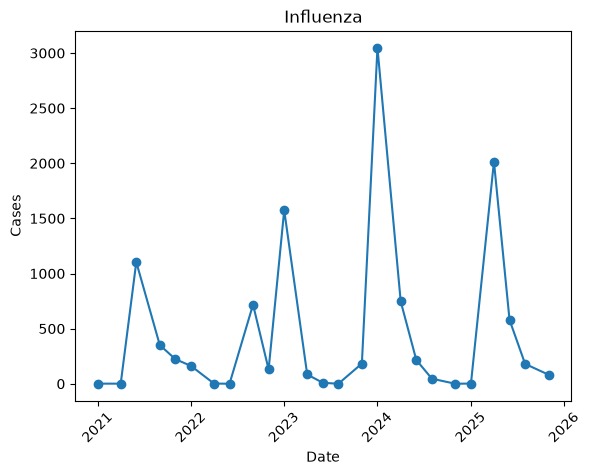

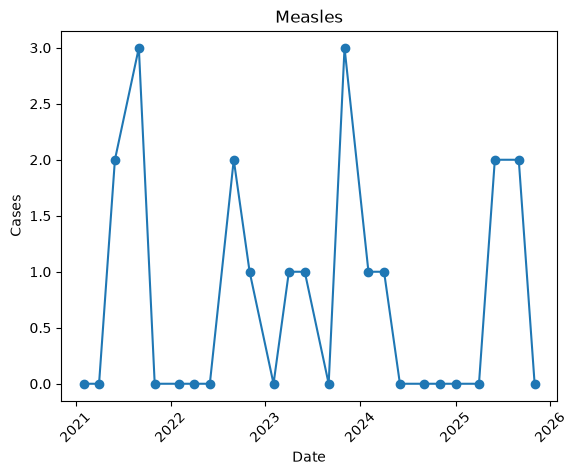

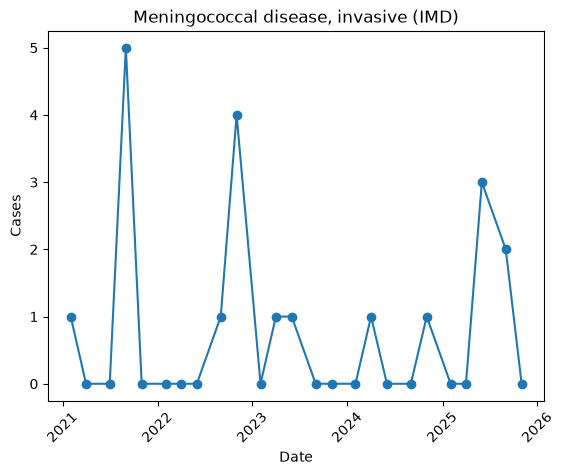

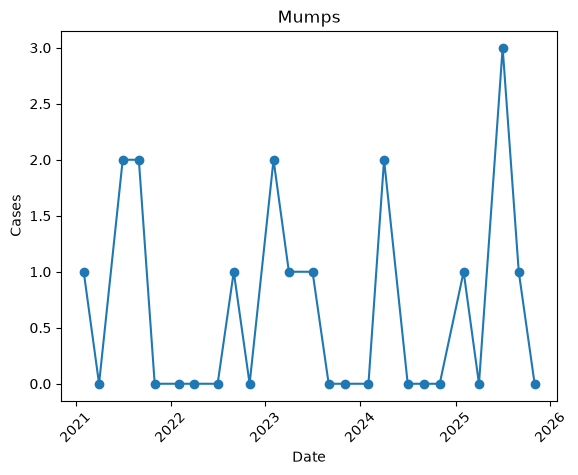

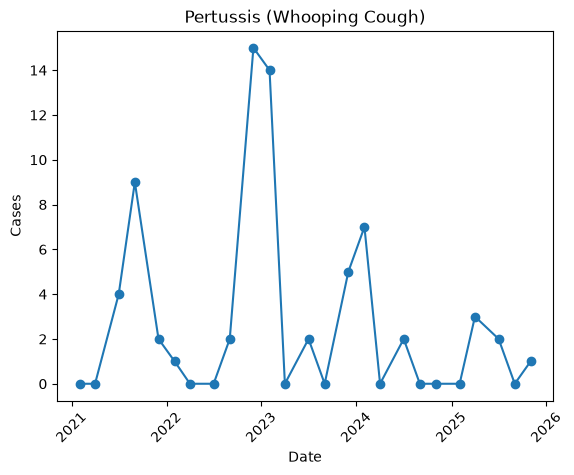

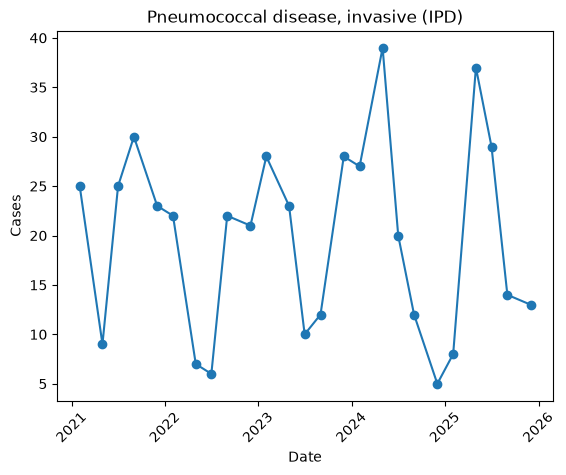

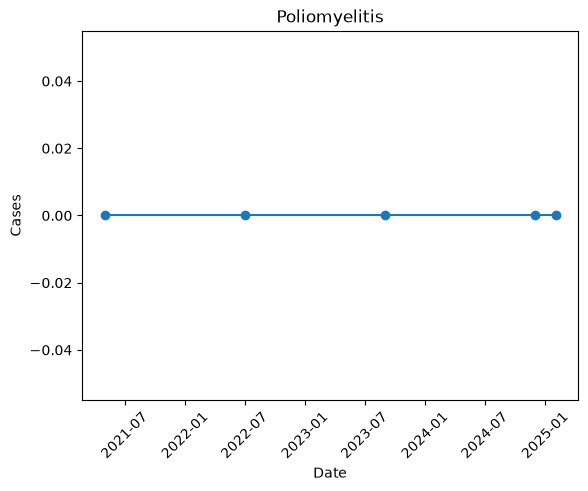

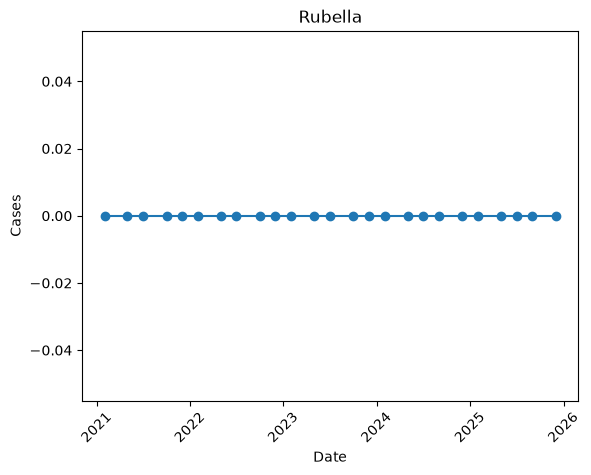

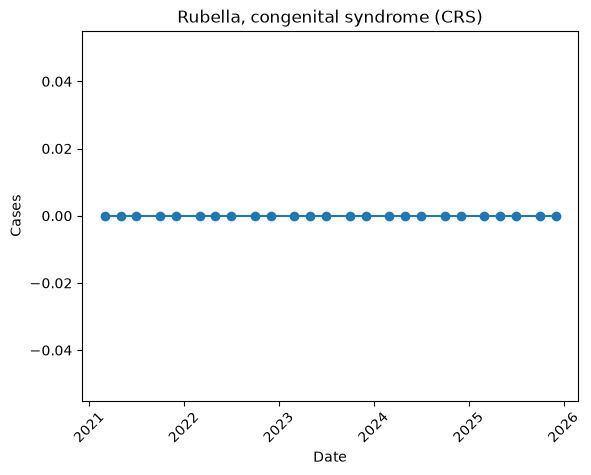

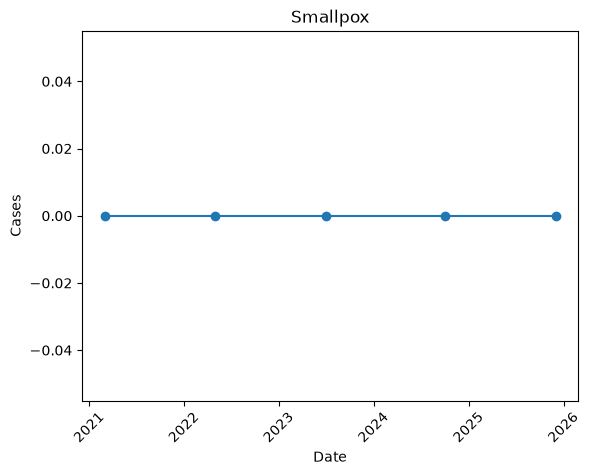

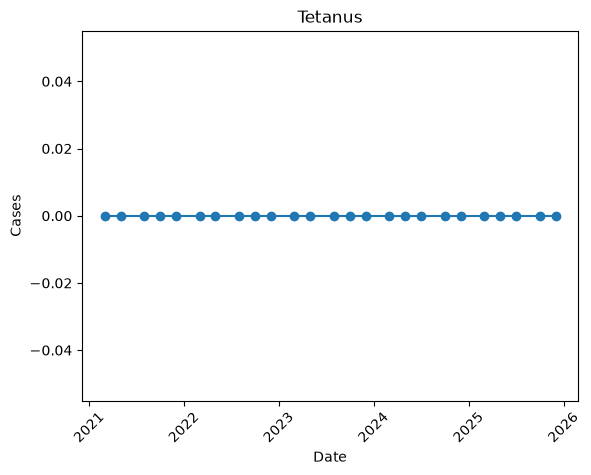

In [18]:
for dis in vacc_mon_data["Disease"].unique():
    cat_data = vacc_mon_data[vacc_mon_data["Disease"] == dis].sort_values("Date")
    
    plt.plot(
        cat_data["Date"],
        cat_data["Cases"],
        marker="o"
    )

    plt.title(dis)
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.xticks(rotation=45)

    plt.show()